# Phase 1 — Exercise × Exercise Recommender (Explanation)

This explains each section of our **item-based (exercise × exercise)** baseline recommender in **simple language**, step by step.

---

## 1 - Imports and Helper Functions

### What We Did
We imported Python libraries like `pandas`, `numpy`, `matplotlib`, and `sklearn` for handling data, math, and charts.  
We also created small helper functions to clean and process text data.

### Why We Did It
Some columns (like `ExThreat` and `ExTTPs`) have multiple items separated by commas or semicolons.  
The helpers clean these up and make them easier to work with.

We also added a function called `row_minmax()` to **scale similarity values** between 0 and 1.

### Example
If one exercise has “Phishing; Malware”, we turn it into: `['phishing', 'malware']` and tag them like:
`threat:phishing ttp:malware`


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ---- helpers (same style as PDF) ----
def split_multi(x):
    if pd.isna(x):
        return []
    s = str(x).replace("|", ";").replace(",", ";")
    return [re.sub(r"\s+", "_", t.strip().lower()) for t in s.split(";") if t.strip()]

def prefixed_text(row, mapping):
    toks = []
    for col, pref in mapping:
        toks += [f"{pref}{v}" for v in split_multi(row.get(col, ""))]
    return " ".join(sorted(set(toks)))  # dedup tokens

def row_minmax(S, eps=1e-12):
    S = S.copy().astype(float)
    mn = S.min(axis=1, keepdims=True)
    mx = S.max(axis=1, keepdims=True)
    return (S - mn) / (mx - mn + eps)


## 2 Load the Exercises and Build TF-IDF

### What We Did
We loaded the `exercises_full.csv` dataset and selected descriptive columns:
- `ExThreat`
- `ExTTPs`

Then, we combined them into a single text for each exercise, like:
`threat:phishing ttp:T1059.001 ttp:T1566`

We used **TF-IDF (Term Frequency – Inverse Document Frequency)** to turn this text into numbers.

### Why We Did It
TF-IDF helps us measure how *important* each word (TTP or threat) is compared to all other exercises.  
This converts exercises into numerical vectors so we can calculate similarity mathematically.

---


In [3]:
# Load your exercises table
exs = pd.read_csv("exercises_full.csv")

# Choose which columns describe an exercise
# (adjust if you have different names available)
ex_map = [
    ("ExThreat", "threat:"),
    ("ExTTPs",   "ttp:"),
    # add more if you want:
    # ("ExCategories", "cat:"),
    # ("ExStructure",  "struct:"),
]

# Create a token string per exercise (like in the PDF, but exercises-only)
ex_text = exs.apply(lambda r: prefixed_text(r, ex_map), axis=1)

print(ex_text[0])

# Build TF-IDF space for exercises
vec = TfidfVectorizer(tokenizer=str.split, token_pattern=None)
X_ex = vec.fit_transform(ex_text)
X_ex.toarray()


threat:ransomware ttp:access_token_manipulation ttp:credential_dumping ttp:defense_evasion ttp:process_injection


array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.46483095, 0.        , 0.        , ..., 0.46483095, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.34802134, ..., 0.34802134, 0.        ,
        0.        ]])

## 3 Exercise × Exercise Similarity

### What We Did
We used **cosine similarity** to compare every exercise with every other exercise.  
This created a big square matrix (a grid) where:
- Each row = one exercise  
- Each column = another exercise  
- Each cell = how similar they are (from 0 to 1)

Then, we scaled each row to [0, 1] so that 1 means “most similar.”

### Why We Did It
This matrix is the **heart of our recommender**.  
It tells us which exercises are most alike based on their content (TTPs and threats).

We saved the result as: ex_sim.npz

In [4]:
# Cosine similarity between every pair of exercises
S_ex = cosine_similarity(X_ex)  # shape: (n_ex, n_ex)

# Make diagonal the row max before scaling so each row reaches 1.0
np.fill_diagonal(S_ex, S_ex.max())

# Scale each row to [0,1] (same style as PDF)
S_ex_scaled = row_minmax(S_ex)

# Save for later use (dashboard/phase two hybrid, etc.)
np.savez_compressed("ex_sim.npz", S=S_ex_scaled)

print("ex_sim.npz saved. Shape:", S_ex_scaled.shape)

S_ex_scaled

ex_sim.npz saved. Shape: (30, 30)


array([[1.        , 0.        , 0.15500246, 0.        , 0.26749574,
        0.        , 0.11977566, 0.17134486, 0.2069511 , 0.        ,
        0.        , 0.        , 0.        , 0.09513805, 0.        ,
        0.        , 0.1101634 , 0.13981465, 0.        , 0.09554456,
        0.        , 0.27994319, 0.        , 0.        , 0.        ,
        0.09804142, 0.0871061 , 0.1967374 , 0.        , 0.        ],
       [0.        , 1.        , 0.        , 0.18586446, 0.        ,
        0.17216423, 0.        , 0.        , 0.        , 0.        ,
        0.14855247, 0.22422703, 0.        , 0.        , 0.        ,
        0.45272724, 0.17755409, 0.        , 0.14085399, 0.        ,
        0.        , 0.        , 0.26733443, 0.        , 0.14865773,
        0.14011677, 0.26488033, 0.        , 0.35240068, 0.16177109],
       [0.15500246, 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.12480686, 0.17854224, 0.21564412, 0.        ,
        0.        , 0.        , 0.        , 0.

## 4 - Find Top-K Similar Exercises

### What We Did
For each exercise, we picked the **Top-K (e.g., 5)** most similar exercises.  
We excluded the exercise itself, since it’s always 100 % similar to itself.

### Why We Did It
These Top-K results are what we’ll recommend:
> “If you liked this exercise, here are 5 others that are most similar.”


In [5]:
# Build EXID index maps (assumes a column named 'EXID')
ex_ids = exs["EXID"].astype(int).tolist()
exid2ix = {exid: i for i, exid in enumerate(ex_ids)}
ix2exid = {i: exid for exid, i in exid2ix.items()}

def topk_similar_exercises(ex_id, K=5, exclude_self=True):
    """Return [(EXID, score), ...] top-K similar to ex_id."""
    i = exid2ix[int(ex_id)]
    row = S_ex_scaled[i].copy()
    if exclude_self:
        row[i] = -1.0  # remove self
    idx = np.argsort(-row)[:K]
    return [(ix2exid[j], float(row[j])) for j in idx]

# Example:
print(topk_similar_exercises(ex_id=ex_ids[0], K=5))


[(22, 0.2799431944485512), (5, 0.2674957381814029), (9, 0.20695109772999914), (28, 0.196737404586379), (8, 0.17134486270174742)]


## 5 - Heatmap Visualization

### What We Did
We plotted the similarity matrix as a **heatmap**.  
Each row and column is an exercise, and colors show how similar they are.

- Bright yellow → very similar  
- Dark blue → not similar

### Why We Did It
It gives a quick, visual overview of how exercises are related or grouped together.  
The diagonal is always bright because each exercise is perfectly similar to itself.

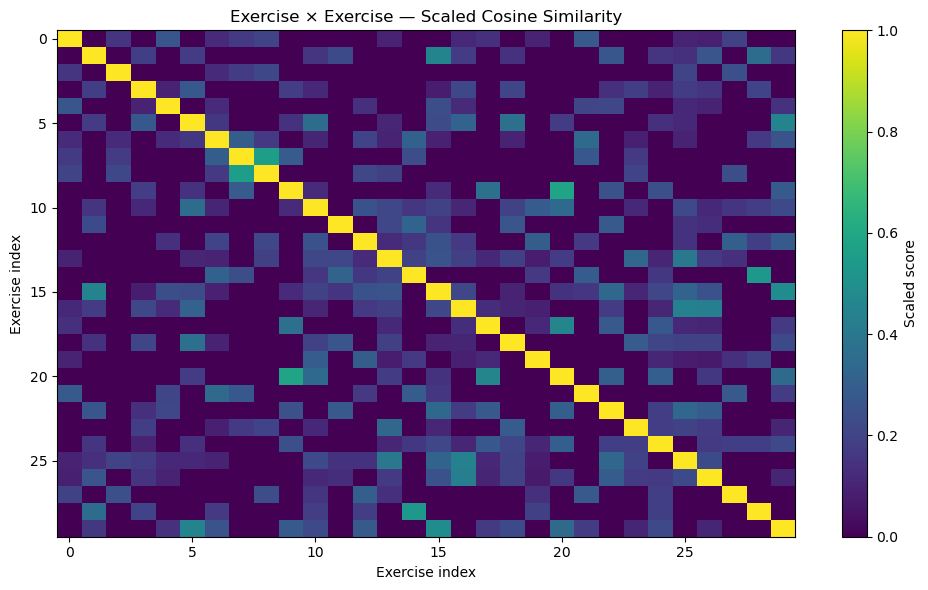

In [13]:
def plot_ex_heatmap(S_scaled, vmax=1.0):
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(S_scaled, aspect="auto", vmin=0, vmax=vmax)
    ax.set_title("Exercise × Exercise — Scaled Cosine Similarity")
    ax.set_xlabel("Exercise index")
    ax.set_ylabel("Exercise index")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Scaled score")
    plt.tight_layout()
    plt.show()

plot_ex_heatmap(S_ex_scaled)



## 6 - Bar Chart for Top-K Similar Exercises

### What We Did
We made a simple bar chart showing the Top-5 most similar exercises for any chosen exercise.

### Why We Did It
This helps us and our client **see which exercises are related** and how strong the similarities are.
It’s easy to explain in meetings and presentations.

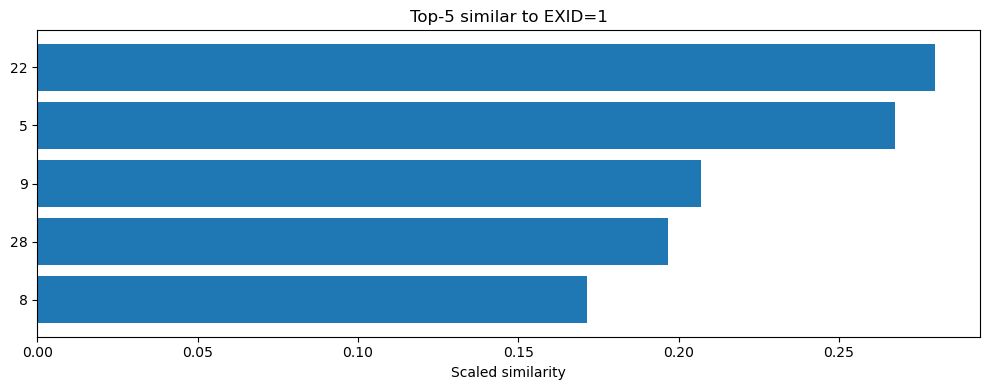

In [14]:
def plot_topk_for_ex(ex_id, K=5, name_col=None):
    i = exid2ix[int(ex_id)]
    row = S_ex_scaled[i].copy()
    row[i] = -1.0  # exclude self
    idx = np.argsort(-row)[:K]
    ys  = row[idx]
    if name_col and name_col in exs.columns:
        labels = [f"{ix2exid[j]} — {exs.iloc[j][name_col]}" for j in idx]
    else:
        labels = [str(ix2exid[j]) for j in idx]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(range(K), ys[::-1])
    ax.set_yticks(range(K), labels[::-1])
    ax.set_xlabel("Scaled similarity")
    ax.set_title(f"Top-{K} similar to EXID={ex_id}")
    plt.tight_layout()
    plt.show()

# Example (set a valid EXID from your data):
plot_topk_for_ex(ex_id=ex_ids[0], K=5, name_col=None)  # or name_col="ExName"


## 7 - Export Top-K Results to CSV

### What We Did
We exported the Top-5 similar exercises for each exercise into: `exercise_item_item_topk.csv`


### Why We Did It
So others (like the Phase 2 collaborative filtering team or dashboard developer) can use these ready-made recommendations.  
It also helps in verifying and testing results later.

In [6]:
def export_topk_all_exercises(K=5, out_csv="exercise_item_item_topk.csv"):
    rows = []
    for ex_id in ex_ids:
        recs = topk_similar_exercises(ex_id, K=K, exclude_self=True)
        rows.append({"EXID": int(ex_id), "TOPK_SIMILAR": [r[0] for r in recs]})
    pd.DataFrame(rows).to_csv(out_csv, index=False)
    print("Saved:", out_csv)

export_topk_all_exercises(K=5)


Saved: exercise_item_item_topk.csv




## In Short

| Step | What It Does | Why It’s Important |
|------|---------------|--------------------|
| 1. Imports & Helpers | Clean data and create utility functions | Makes rest of code simple and clean |
| 2. TF-IDF Encoding | Turn text (TTPs & threats) into numbers | Allows exercises to be compared mathematically |
| 3. Similarity Matrix | Compute cosine similarity between exercises | Core of item-item recommender |
| 4. Top-K Extraction | Pick Top-5 most similar per exercise | Actual recommendations |
| 5. Heatmap Plot | Visualize similarity patterns | Easy to see clusters of related exercises |
| 6. Top-K Bar Chart | Show similar items for one exercise | Good for explanation and demo |
| 7. Export CSV | Save Top-K results | Useful for later phases and dashboard |

---

## How to Explain to the Team

- **Start simple:** “We’re finding which exercises are most alike based on their MITRE TTPs and threat tags.”
- **Explain the flow:** Text → TF-IDF → Cosine Similarity → Top-K → Visualization.
- **Use an example:** Pick one exercise and show its top-5 similar ones.
- **End with takeaway:**  
  “This is our *Phase 1 baseline*. Later, in Phase 2, we’ll use collaborative filtering and hybrid models to make the recommendations even smarter.”
